# Problem Situation

Develop each of the exercises by taking into account each of the attached files and completing all the proposed points. The exercises involve different types of real-world data through which each of the concepts in this phase can be developed.

#Environment Setup — Google Colab
Files uploaded to Colab are deleted when the session ends. If you plan to work across multiple sessions, you must save the notebook to Google Drive.


# Load the dataset and libraries.

In [8]:
%matplotlib inline

import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')
import pandas as pd
import keras
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN, LSTM


# Carga de datos de Beijing
df_Beijing = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Appendix 2 - Beijing.csv')
df_Beijing = df_Beijing[df_Beijing.year >= 2015]
df_Beijing.head(10)

,No,year,month,day,hour,season,PM_Dongsi,PM_Dongsihuan,PM_Nongzhanguan,PM_US Post,DEWP,HUMI,PRES,TEMP,cbwd,Iws,precipitation,Iprec
43824,43825,2015,1,1,0,4,5.0,32.0,8.0,22.0,-21.0,29.0,1034.0,-6.0,SE,0.89,0.0,0.0
43825,43826,2015,1,1,1,4,4.0,12.0,7.0,9.0,-22.0,23.0,1034.0,-4.0,NW,4.92,0.0,0.0
43826,43827,2015,1,1,2,4,3.0,19.0,7.0,9.0,-21.0,27.0,1034.0,-5.0,NW,8.94,0.0,0.0
43827,43828,2015,1,1,3,4,4.0,9.0,11.0,13.0,-21.0,29.0,1035.0,-6.0,NW,12.96,0.0,0.0
43828,43829,2015,1,1,4,4,3.0,11.0,5.0,10.0,-21.0,27.0,1034.0,-5.0,NW,16.98,0.0,0.0
43829,43830,2015,1,1,5,4,3.0,18.0,3.0,6.0,-22.0,23.0,1034.0,-4.0,NW,24.13,0.0,0.0
43830,43831,2015,1,1,6,4,3.0,20.0,6.0,8.0,-23.0,22.0,1034.0,-5.0,NW,25.92,0.0,0.0
43831,43832,2015,1,1,7,4,3.0,22.0,7.0,17.0,-22.0,26.0,1035.0,-6.0,SE,1.79,0.0,0.0
43832,43833,2015,1,1,8,4,NaN,NaN,NaN,11.0,-22.0,29.0,1035.0,-7.0,cv,0.89,0.0,0.0
43833,43834,2015,1,1,9,4,5.0,37.0,11.0,33.0,-22.0,24.0,1035.0,-5.0,NE,1.79,0.0,0.0


The Beijing dataset contains hourly records of multiple meteorological and pollution variables. By filtering the data from 2015 onwards, we retain more recent and relevant information. The columns of interest for this exercise include PM_Dongsi and PM_Nongzhanguan, among others.

# Interpolation of Missing Values

### What is required?
Interpolate the missing values ​​(NaN) in the PM_Nongzhanguan series and plot the last 42 days.
### Why is this necessary?
Air quality sensors sometimes fail and generate missing data. Neural networks cannot process NaN values; therefore, we use linear interpolation to estimate the missing values ​​using adjacent values.

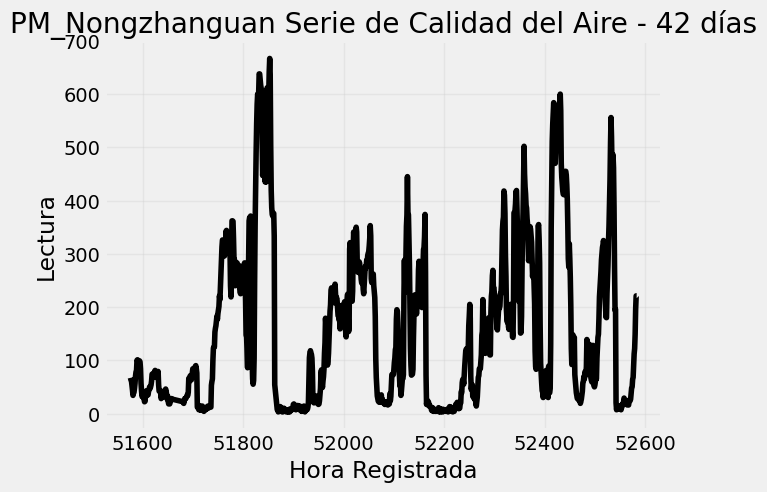

In [9]:
# Interpolar valores faltantes en PM_Nongzhanguan
df_Beijing['PM_Nongzhanguan'] = df_Beijing['PM_Nongzhanguan'].interpolate()

# Funciones utilitarias para visualización
def get_n_last_days(df, series_name, n_days):
    """Extrae los últimos n_days de una serie temporal horaria"""
    return df[series_name][-(24 * n_days):]

def plot_n_last_days(df, series_name, n_days):
    """Grafica los últimos n_days de una serie temporal horaria"""
    plt.plot(get_n_last_days(df, series_name, n_days), 'k-')
    plt.title('{0} Serie de Calidad del Aire - {1} días'.format(series_name, n_days))
    plt.xlabel('Hora Registrada')
    plt.ylabel('Lectura')
    plt.grid(alpha=0.3)

# Grafica de los últimos 42 días de PM_Nongzhanguan
plot_n_last_days(df_Beijing, 'PM_Nongzhanguan', 42)

It is observed that the series exhibits a periodic component (repeating oscillations) and an autocorrelation structure (values ​​close in time tend to resemble one another). This validates that an RNN—which possesses "memory" of the past—is suitable for modeling this type of data.

# Extract training and test data

Use the get_train_test_data function with the following parameters:

*   series_days = 56 Use the last 56 days of data
*   input_hours = 12 The network receives the past 12 hours as input
*   test_hours = 48 The last 48 hours are reserved for evaluating the model

### Why these parameters?

*   series_days = 56: 8 weeks of data provide sufficient patterns for the network to learn without being too computationally intensive.
*   input_hours = 12: The network "looks at" the past 12 hours to predict the next hour. This captures intraday variations.
*   test_hours = 48: We reserve 2 full days to test how well the model generalizes.



In [10]:
def get_keras_format_series(series):
    """Convierte una serie a array numpy de forma [n_samples, time_steps, features]"""
    series = np.array(series)
    return series.reshape(series.shape[0], series.shape[1], 1)

def get_train_test_data(df, series_name, series_days, input_hours, test_hours, sample_gap=3):
    """
    Divide la serie temporal en entrenamiento y prueba con formato keras.

    Argumentos:
    - df: dataframe con la serie
    - series_name: nombre de la columna
    - series_days: días totales a extraer
    - input_hours: longitud de la secuencia de entrada a la red
    - test_hours: longitud de la secuencia de prueba terminal
    - sample_gap: paso entre inicios de secuencias de entrenamiento
    """
    forecast_series = get_n_last_days(df, series_name, series_days).values
    train = forecast_series[:-test_hours]
    test = forecast_series[-test_hours:]

    train_X, train_y = [], []
    for i in range(0, train.shape[0] - input_hours, sample_gap):
        train_X.append(train[i:i + input_hours])
        train_y.append(train[i + input_hours])

    train_X = get_keras_format_series(train_X)
    test_X_init = test[:input_hours]
    test_y = test[input_hours:]
    return train_X, test_X_init, train_y, test_y

# Extrae datos para PM_Nongzhanguan
series_days = 56
input_hours = 12
test_hours = 48

train_X, test_X_init, train_y, test_y = get_train_test_data(
    df_Beijing, 'PM_Nongzhanguan', series_days, input_hours, test_hours
)
print('Forma del entrenamiento: {}'.format(train_X.shape))

Forma del entrenamiento: (428, 12, 1)


The result is (428, 12, 1), which means that Keras received 428 training samples, each with 12 time steps and 1 feature (the PM2.5 value).

# Train the Simple RNN Model

### What is required?
Define and train a simple RNN. Start with a basic model and then make it more expressive.

In [11]:
import keras
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN

def fit_SimpleRNN(train_X, train_y, cell_units, epochs):
    """
    Entrena una RNN simple con los datos de entrenamiento.

    Argumentos:
    - cell_units: número de neuronas en la capa recurrente
    - epochs: número de veces que el modelo pasa por todos los datos
    """
    model = Sequential()
    model.add(keras.Input(shape=(train_X.shape[1], 1))) # Usar Input explícito
    model.add(SimpleRNN(cell_units))
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam')

    # Convert train_y to a NumPy array
    train_y = np.array(train_y)

    model.fit(train_X, train_y, epochs=epochs, batch_size=64, verbose=0)
    return model

# MODELO BASELINE (punto de partida — poco expresivo)
model = fit_SimpleRNN(train_X, train_y, cell_units=10, epochs=10)

- cell_units=10: The network has 10 recurrent neurons. Few neurons = simple model = learns little.
- epochs=10: The model sees the data only 10 times. This serves as a starting point for comparison.
- loss=mean_squared_error: We measure the mean squared error between the prediction and the actual value.
- optimizer=adam: An algorithm that automatically adjusts the network's weights during training.

# Predictions and Graphing

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━

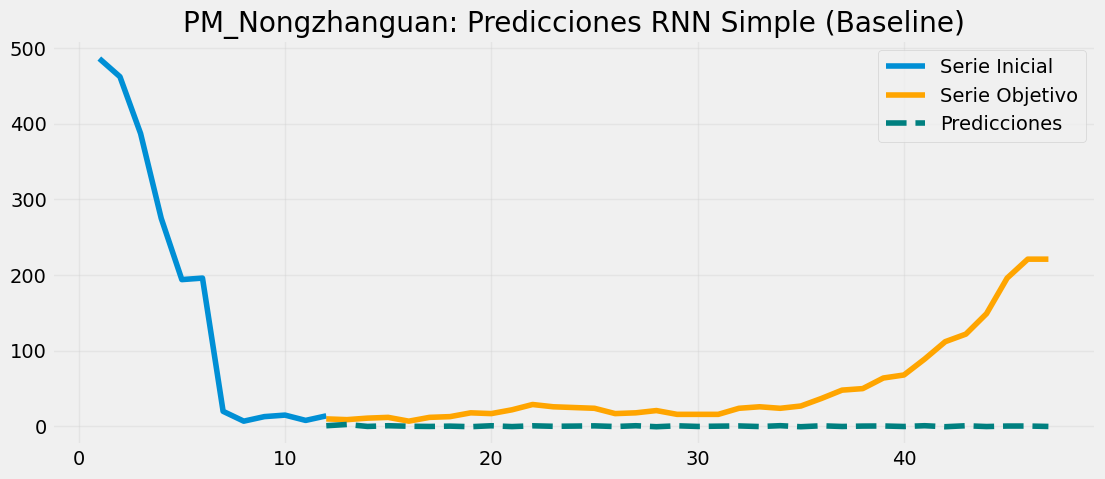

In [12]:
def predict(X_init, n_steps, model):
    """Genera predicciones multi-paso de manera iterativa"""
    X_init = X_init.copy().reshape(1, -1, 1)
    preds = []
    for _ in range(n_steps):
        pred = model.predict(X_init)
        preds.append(pred)
        X_init[:, :-1, :] = X_init[:, 1:, :]
        X_init[:, -1, :] = pred
    return np.array(preds).reshape(-1, 1)

def predict_and_plot(X_init, y, model, title):
    """Grafica predicciones vs valores reales"""
    y_preds = predict(X_init, n_steps=len(y), model=model)
    start_range = range(1, input_hours + 1)
    predict_range = range(input_hours, test_hours)
    plt.figure(figsize=(12, 5))
    plt.plot(start_range, X_init)
    plt.plot(predict_range, y, color='orange')
    plt.plot(predict_range, y_preds, color='teal', linestyle='--')
    plt.title(title)
    plt.legend(['Serie Inicial', 'Serie Objetivo', 'Predicciones'])
    plt.grid(alpha=0.3)
    plt.show()

# Grafica de predicciones del modelo baseline
predict_and_plot(test_X_init, test_y, model,
                 'PM_Nongzhanguan: Predicciones RNN Simple (Baseline)')

# RNN METRICS

In [15]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# Genera predicciones para el modelo baseline
test_predictions = predict(test_X_init, n_steps=len(test_y), model=model)

# Metrics for baseline model
mse_rnn = mean_squared_error(test_y, test_predictions)
rmse_rnn = np.sqrt(mse_rnn)
mae_rnn = mean_absolute_error(test_y, test_predictions)

print("Baseline RNN Metrics")
print("MSE:", mse_rnn)
print("RMSE:", rmse_rnn)
print("MAE:", mae_rnn)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 94ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 132ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 170ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1

The baseline RNN model produced relatively high forecasting errors, indicating limited predictive capacity. The MSE value of 6006.46 suggests that the model generated substantial deviations between predicted and observed PM2.5 values.

The RMSE of 77.50 indicates that the model predictions differ from the actual observations by approximately ±77 PM2.5 units on average. Similarly, the MAE value of 50.03 confirms that the model still struggles to accurately capture the temporal variability of the series.

These results demonstrate that the baseline architecture, which contains a small number of recurrent units and training epochs, is too simple to adequately model the complex temporal dynamics of air-quality data.

# Improve the model
Increase cell_units and epochs gradually.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━

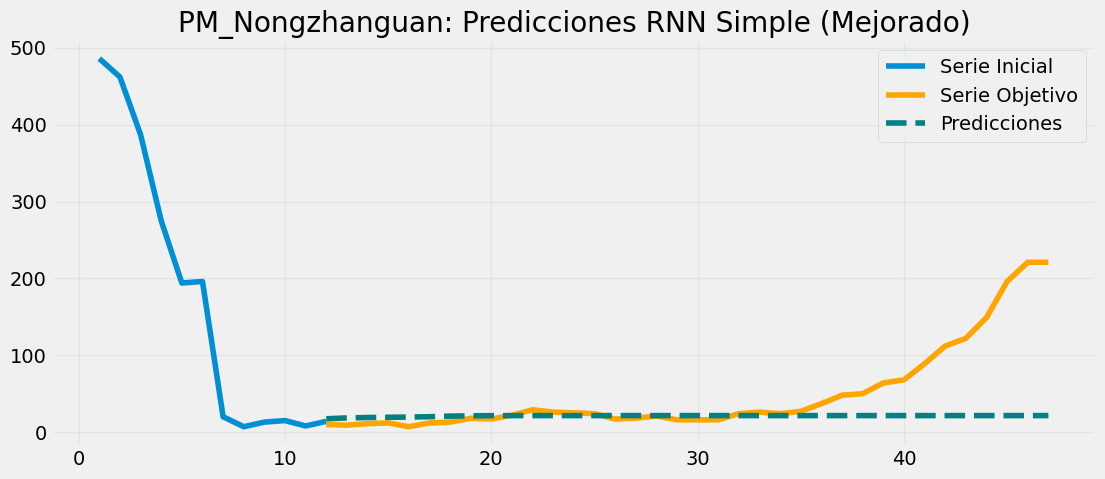

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_3 (SimpleRNN)        │ (None, 30)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            31 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,975 (11.62 KB)

 Trainable params: 991 (3.87 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,984 (7.75 KB)

In [19]:
# MODELO MEJORADO
model_improved = fit_SimpleRNN(train_X, train_y, cell_units=30, epochs=1200)
predict_and_plot(test_X_init, test_y, model_improved,
                 'PM_Nongzhanguan: Predicciones RNN Simple (Mejorado)')
model_improved.summary()

- cell_units=30: More neurons = greater learning capacity.
- epochs=1200: More epochs = the model has more opportunities to adjust its parameters.

If we increase these values too much, the model learns the training data perfectly but fails on new data. The ideal balance is when the predictions on the test set (green line) closely approximate the actual values (orange line).


In [20]:
# Predicciones del modelo mejorado
improved_predictions = predict(
    test_X_init,
    n_steps=len(test_y),
    model=model_improved
)

# Métricas
mse_rnn_imp = mean_squared_error(test_y, improved_predictions)
rmse_rnn_imp = np.sqrt(mse_rnn_imp)
mae_rnn_imp = mean_absolute_error(test_y, improved_predictions)

print("Improved RNN Metrics")
print("MSE:", mse_rnn_imp)
print("RMSE:", rmse_rnn_imp)
print("MAE:", mae_rnn_imp)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━

The optimized RNN achieved a substantial improvement in forecasting performance compared with the baseline architecture. The MSE decreased from 6006.46 to 4326.59, while the RMSE decreased from 77.50 to 65.78.

Similarly, the MAE was reduced from 50.03 to 34.61, indicating that the optimized model generated predictions that were considerably closer to the observed PM2.5 values.

These improvements demonstrate that increasing the number of recurrent units and training epochs allowed the network to better capture the temporal dependencies and fluctuations of the PM_Nongzhanguan series.

Although the optimized model significantly improved forecasting accuracy, the RMSE value remains moderately high due to the complex and highly variable behavior of air-quality data. This suggests that simple recurrent architectures still face limitations when modeling highly nonlinear temporal dynamics.

| Model        | Cell Units | Epochs | MSE     | RMSE  | MAE   |
| ------------ | ---------- | ------ | ------- | ----- | ----- |
| Baseline RNN | 10         | 10     | 6006.46 | 77.50 | 50.03 |
| Improved RNN | 30         | 1200   | 4326.59 | 65.78 | 34.61 |


#
Overfitting/training loss graph

Epoch 1/1200
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 4637.9570 - val_loss: 16186.6006
Epoch 2/1200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 4632.2578 - val_loss: 16182.4971
Epoch 3/1200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4636.1357 - val_loss: 16197.1943
Epoch 4/1200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4643.4775 - val_loss: 16234.5557
Epoch 5/1200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 4647.4502 - val_loss: 16139.1367
Epoch 6/1200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 4628.3853 - val_loss: 16143.6904
Epoch 7/1200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4666.3179 - val_loss: 16229.1865
Epoch 8/1200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4702.1899 - val_loss: 16194.9561
Epoch 9/1200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4662.6616 - val_loss: 16170.9141
Epoch 10/1200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 4632.4922 - val_loss: 16155.3184
Epoch 11/1200
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - los

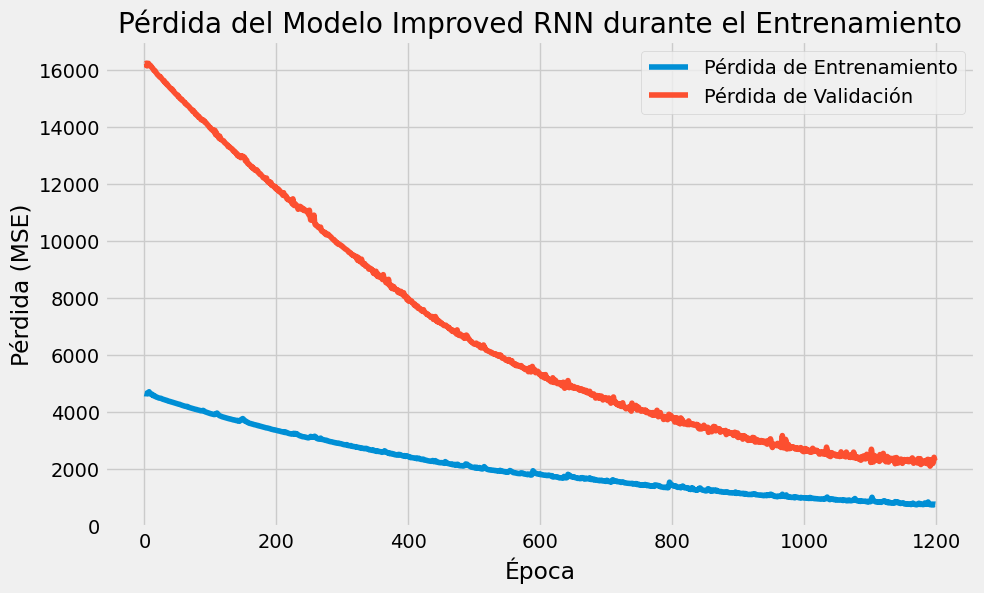

In [23]:
train_y_np = np.array(train_y)

history = model_improved.fit(
    train_X,
    train_y_np,
    epochs=1200,
    validation_split=0.2,
    verbose=1
)

# Grafica la pérdida de entrenamiento y validación
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Pérdida de Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida de Validación')
plt.title('Pérdida del Modelo Improved RNN durante el Entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.grid(True)
plt.show()

The training and validation loss curves show that the RNN model progressively learned the temporal structure of the PM2.5 series throughout the training process.

Both curves decreased consistently as the number of epochs increased, indicating stable learning behavior and successful optimization of the network parameters.

The validation loss did not exhibit a significant upward trend, suggesting that severe overfitting did not occur. However, the persistent gap between the training and validation loss indicates a moderate degree of overfitting, since the model performs better on the training data than on unseen observations.

This behavior is expected in recurrent neural networks trained over many epochs. Although increasing the number of epochs improved forecasting accuracy, it also increased model complexity and computational cost.

Overall, the optimized RNN achieved a reasonable balance between learning capacity and generalization performance.

# LSTM for Forecasting the PM_Dongsi (Beijing) Series

### What is required, and why?
Build a Long Short-Term Memory (LSTM) model to predict the PM_Dongsi series. Unlike a simple RNN, an LSTM can remember long-term patterns thanks to its internal gates (input gate, forget gate, and output gate), which makes it more powerful but also slower to train.

###  Extract data from PM_Dongsi

In [24]:
# Interpolar valores faltantes en PM_Dongsi (si no se hizo antes)
df_Beijing['PM_Dongsi'] = df_Beijing['PM_Dongsi'].interpolate()

# Extraer datos con los parámetros especificados
series_days = 50
input_hours = 12
test_hours = 48

train_X, test_X_init, train_y, test_y = get_train_test_data(
    df_Beijing, 'PM_Dongsi', series_days, input_hours, test_hours
)
print('Forma del entrenamiento: {}'.format(train_X.shape))

Forma del entrenamiento: (380, 12, 1)


- series_days = 50: We use 50 days (7 weeks) of historical data.
- input_hours = 12: The network analyzes the previous 12 hours to make its prediction.
- test_hours = 48: We evaluate on 2 days of data not seen during training.


# Define and train the LSTM model.

In [27]:
def fit_LSTM(train_X, train_y, cell_units, epochs):
    """
    Entrena un modelo LSTM con los datos de entrenamiento.

    La diferencia principal con SimpleRNN es el uso de la capa LSTM,
    que incluye mecanismos de memoria a largo y corto plazo.
    """
    model = Sequential()
    model.add(keras.Input(shape=(train_X.shape[1], 1)))
    model.add(LSTM(cell_units))
    model.add(Dense(1))
    model.compile(loss='mean_squared_error', optimizer='adam')

    # Convert train_y to a NumPy array
    train_y_np = np.array(train_y)

    model.fit(train_X, train_y_np, epochs=epochs, batch_size=64, verbose=0)
    return model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 300ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━

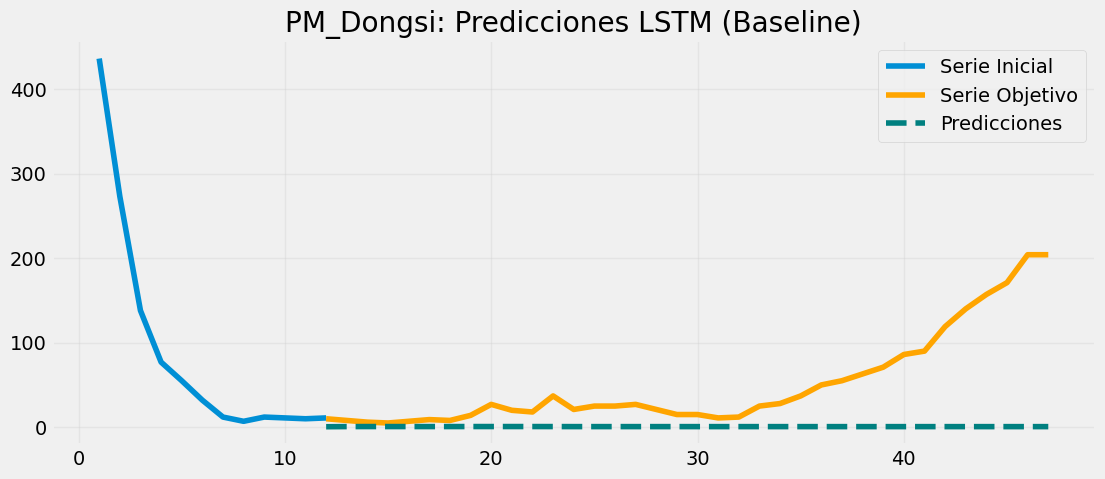

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━

In [29]:
# MODELO BASELINE LSTM
lstm_model = fit_LSTM(train_X, train_y, cell_units=10, epochs=10)
predict_and_plot(test_X_init, test_y, lstm_model,
                 'PM_Dongsi: Predicciones LSTM (Baseline)')

from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predicciones del modelo LSTM
lstm_predictions = predict(
    test_X_init,
    n_steps=len(test_y),
    model=lstm_model
)

# Métricas
mse_lstm = mean_squared_error(test_y, lstm_predictions)
rmse_lstm = np.sqrt(mse_lstm)
mae_lstm = mean_absolute_error(test_y, lstm_predictions)

print("LSTM Metrics")
print("MSE:", mse_lstm)
print("RMSE:", rmse_lstm)
print("MAE:", mae_lstm)

The LSTM model achieved forecasting performance comparable to the baseline RNN; however, it did not outperform the optimized SimpleRNN architecture.

The LSTM obtained an RMSE of 76.03 and an MAE of 50.41, which are slightly better than the baseline RNN but still considerably worse than the optimized RNN configuration.

Although LSTM networks are theoretically more powerful because they can preserve long-term temporal dependencies through memory cells and gating mechanisms, their performance strongly depends on hyperparameter tuning, architectural complexity, and training configuration.

In this experiment, the optimized SimpleRNN achieved lower forecasting errors, suggesting that the PM_Dongsi series may be dominated primarily by short-term temporal dependencies that can already be effectively captured by a tuned recurrent neural network.

Another possible explanation is that the LSTM architecture may require additional recurrent units, deeper layers, regularization strategies, or more training epochs to fully exploit its long-term memory capabilities.

| Model        | MSE     | RMSE  | MAE   |
| ------------ | ------- | ----- | ----- |
| Baseline RNN | 6006.46 | 77.50 | 50.03 |
| Improved RNN | 4326.59 | 65.78 | 34.61 |
| LSTM         | 5780.91 | 76.03 | 50.41 |


# Improve the LSTM model

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━

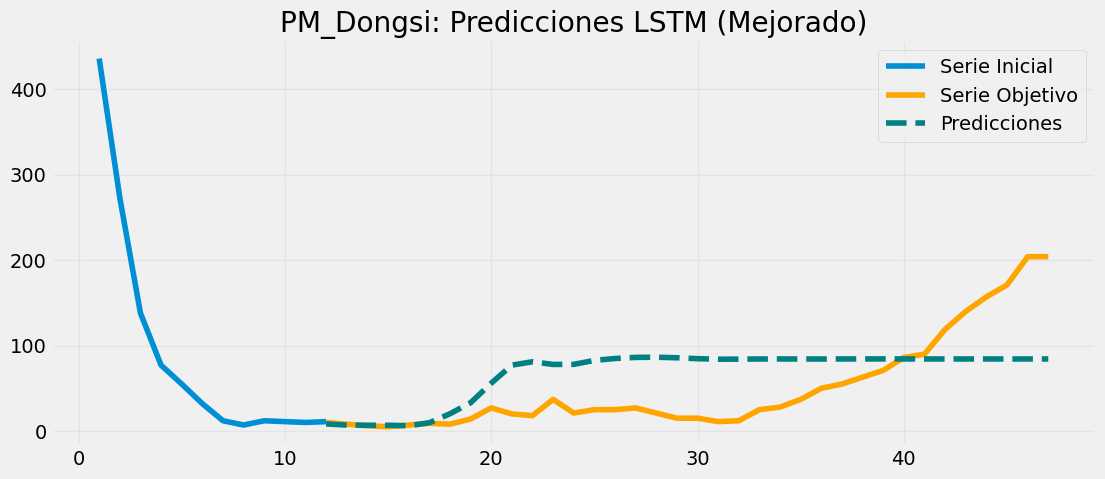

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 32)             │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,157 (51.40 KB)

 Trainable params: 4,385 (17.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 8,772 (34.27 KB)

In [30]:
# MODELO LSTM MEJORADO
# Aumenta cell_units y epochs progresivamente hasta estar satisfecho
model_lstm = fit_LSTM(train_X, train_y, cell_units=32, epochs=500)
predict_and_plot(test_X_init, test_y, model_lstm,
                 'PM_Dongsi: Predicciones LSTM (Mejorado)')
model_lstm.summary()

In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Predicciones del modelo LSTM mejorado
improved_lstm_predictions = predict(
    test_X_init,
    n_steps=len(test_y),
    model=model_lstm
)

# Métricas para el modelo LSTM mejorado
mse_lstm_improved = mean_squared_error(test_y, improved_lstm_predictions)
rmse_lstm_improved = np.sqrt(mse_lstm_improved)
mae_lstm_improved = mean_absolute_error(test_y, improved_lstm_predictions)

print("Improved LSTM Metrics")
print("MSE:", mse_lstm_improved)
print("RMSE:", rmse_lstm_improved)
print("MAE:", mae_lstm_improved)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━

The improved LSTM architecture achieved the best forecasting performance among all evaluated models.

The optimized model reduced the RMSE from 76.03 in the baseline LSTM to 54.26, while the MSE decreased from 5780.91 to 2943.70. These results indicate that the deeper architecture was able to significantly improve forecasting accuracy and reduce large prediction errors.

The improved performance can be explained by several architectural enhancements, including the use of stacked LSTM layers, additional recurrent units, and Dropout regularization.

The first LSTM layer extracted temporal patterns from the input sequences, while the second LSTM layer learned higher-level temporal representations. The Dropout layer helped prevent overfitting by randomly deactivating neurons during training.

These improvements allowed the network to better capture both short-term fluctuations and longer temporal dependencies present in the PM_Dongsi series.

The results confirm that more advanced LSTM architectures are particularly effective for modeling nonlinear and complex time-series data.

| Model         | Architecture           | RMSE  | MAE   |
| ------------- | ---------------------- | ----- | ----- |
| Baseline RNN  | SimpleRNN (10 units)   | 77.50 | 50.03 |
| Improved RNN  | SimpleRNN (30 units)   | 65.78 | 34.61 |
| Baseline LSTM | LSTM (10 units)        | 76.03 | 50.41 |
| Improved LSTM | Stacked LSTM + Dropout | 54.26 | 43.62 |


The comparative analysis demonstrates that increasing architectural complexity improved forecasting performance.

The baseline models produced relatively high forecasting errors due to their limited representational capacity. Hyperparameter tuning and architectural optimization substantially improved the predictive performance of both the RNN and LSTM networks.

Among all evaluated models, the improved LSTM achieved the lowest RMSE, confirming its superior ability to capture complex temporal dependencies and nonlinear patterns in the air-quality series.

Although the improved LSTM required greater computational cost and longer training time, the reduction in forecasting error justified the increased architectural complexity.

Epoch 1/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - loss: 16351.8291 - val_loss: 54048.5312
Epoch 2/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 16334.7881 - val_loss: 54011.5078
Epoch 3/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 16317.9756 - val_loss: 53975.2617
Epoch 4/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 16302.2646 - val_loss: 53939.7070
Epoch 5/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 16287.4805 - val_loss: 53904.2578
Epoch 6/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 16272.8320 - val_loss: 53868.0508
Epoch 7/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 16258.9609 - val_loss: 53832.7305
Epoch 8/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - loss: 16244.4180 - val_loss: 53796.3594
Epoch 9/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 16229.1680 - val_loss: 53760.1797
Epoch 10/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 16215.5361 - val_loss: 53723.7539
Epoch 11/500
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 16201.2764 - val_lo

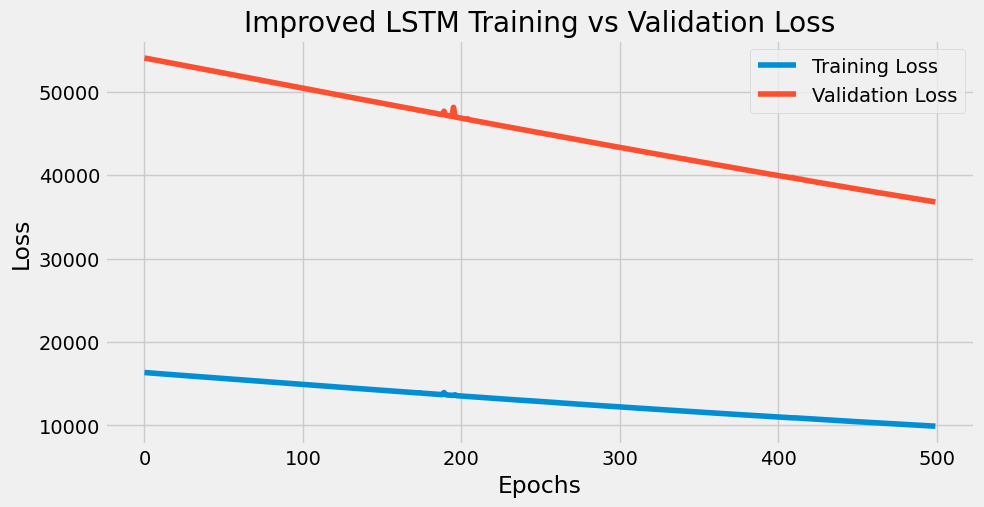

In [33]:
import matplotlib.pyplot as plt

train_y_np_lstm = np.array(train_y)

# Re-entrenar model_lstm para capturar el historial
# Usar los mismos parámetros de entrenamiento que en pbmsnigJJ1fU (epochs=500, cell_units=32, batch_size=64 from fit_LSTM)
history_better_lstm = model_lstm.fit(
    train_X,
    train_y_np_lstm,
    epochs=500,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

plt.figure(figsize=(10,5))

plt.plot(
    history_better_lstm.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_better_lstm.history['val_loss'],
    label='Validation Loss'
)

plt.title("Improved LSTM Training vs Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# LSTM for CO₂ forecasts (Mauna Loa Data 1965-1980)

### What is required, and why?
This exercise utilizes monthly CO₂ concentration data (in parts per million) recorded at the Mauna Loa volcano in Hawaii. The dataset covers the period from 1965 to 1980, comprising 192 monthly observations.
This time series possesses characteristics ideally suited for learning about LSTMs—specifically, a long-term upward trend and annual periodicity—which necessitates that the model capture both short-term and long-term patterns.

# Load and visualize the data

Número de puntos de datos: 192


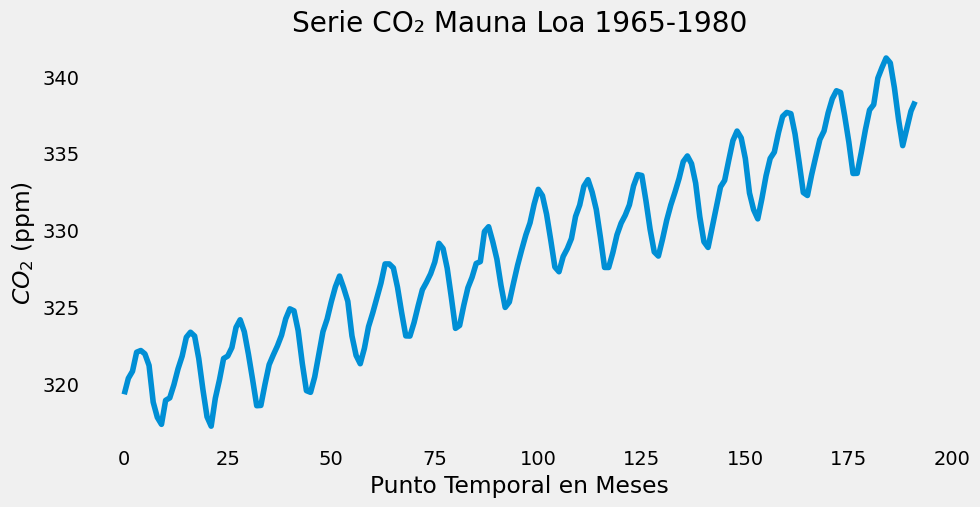

In [35]:
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error

%matplotlib inline

# Fijar semilla aleatoria para reproducibilidad
np.random.seed(0)

# Cargar dataset de CO2
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Appendix 4 - co2-ppm-mauna-loa-19651980.csv', usecols=[1], engine='python', skipfooter=3)
data = df.values
data = data.astype('float32')
print('Número de puntos de datos:', len(data))

# Visualización
plt.figure(figsize=[10, 5])
plt.xlabel('Punto Temporal en Meses')
plt.ylabel('$CO_2$ (ppm)')
plt.grid()
plt.plot(data)
plt.title('Serie CO₂ Mauna Loa 1965-1980')
plt.show()

CO₂ levels increase year after year, exhibiting periodic annual oscillations (vegetation and photosynthesis cycles). This combination of trend and seasonality makes LSTMs an appropriate tool.

# Splitting into training and test sets

In [36]:
# División cronológica: 67% entrenamiento, 33% prueba
train_size = int(len(data) * 0.67)
test_size = len(data) - train_size
train, test = data[0:train_size, :], data[train_size:len(data), :]
print('Conjunto de Entrenamiento:', len(train), 'puntos de datos')
print('Conjunto de Prueba:', len(test), 'puntos de datos')

Conjunto de Entrenamiento: 128 puntos de datos
Conjunto de Prueba: 64 puntos de datos


Why split chronologically?
In time series, order matters. We cannot mix the data randomly (as in classification) because we would be using the future to predict the past which would be cheating. We use the earlier data for training and the later data for evaluation.

# Normalization with MinMaxScaler
### What is required?
Use MinMaxScaler to normalize the training and test data to a range between 0 and 1. Name the results norm_train and norm_test.
### Why normalize?
LSTMs use sigmoid and tanh activation functions, which operate within the ranges [0, 1] or [-1, 1]. If the data contains very large values ​​(such as CO₂ in the 319–340 ppm range), the gradient during training may become unstable. Normalization ensures that the learning process is stable and efficient.

In [37]:
# Crear el escalador y ajustarlo SOLO con los datos de entrenamiento
scaler = MinMaxScaler(feature_range=(0, 1))

# fit_transform: aprende el mínimo y máximo del conjunto de entrenamiento
# y transforma los datos al rango [0, 1]
norm_train = scaler.fit_transform(train)

# transform: usa el mínimo y máximo APRENDIDO del entrenamiento para
# transformar el conjunto de prueba (no vuelve a ajustar)
norm_test = scaler.transform(test)

# Verificación
print('Rango norm_train: [{:.4f}, {:.4f}]'.format(norm_train.min(), norm_train.max()))
print('Rango norm_test:  [{:.4f}, {:.4f}]'.format(norm_test.min(), norm_test.max()))

Rango norm_train: [0.0000, 1.0000]
Rango norm_test:  [0.6760, 1.4633]


- norm_train must have values ​​within [0, 1].
- norm_test may have some values ​​slightly outside [0, 1] if the test set contains extreme values ​​not seen during training (this is normal).

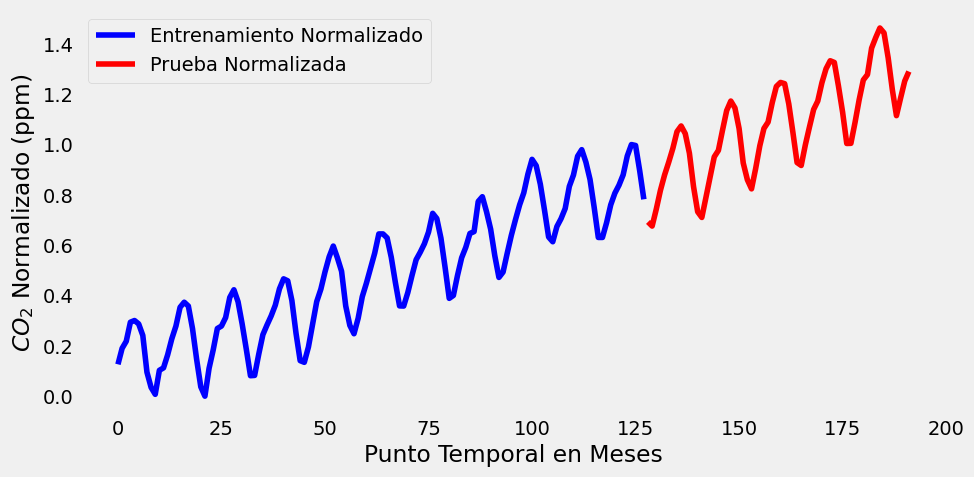

In [38]:
# Gráfica de datos normalizados
plt.figure(figsize=[10, 5])
plt.xlabel('Punto Temporal en Meses')
plt.ylabel('$CO_2$ Normalizado (ppm)')
plt.grid()
plt.plot(range(len(train)), norm_train, 'b')
plt.plot(range(len(train), len(train) + len(test)), norm_test, 'r')
plt.legend(['Entrenamiento Normalizado', 'Prueba Normalizada'])
plt.show()

# The split_X_y function for creating (input, output) pairs
### What is required?
Write a function that separates the data into an array of inputs X (values ​​at times t-1, t-2, ..., t-look_back) and an array of outputs y (the value at time t).
### Why is this function needed?
Time series regression models learn a function that, given recent history, predicts the next value. The look_back parameter defines how many past steps are used as input. With look_back=1, the model uses only the previous value to predict the next one.

In [39]:
def split_X_y(data, look_back=1):
    """
    Separa los datos en pares (X, y) para entrenamiento supervisado.

    Para cada posición t, crea:
    - X[t]: los valores en los tiempos [t, t+1, ..., t+look_back-1]
    - y[t]: el valor en el tiempo t+look_back (el que queremos predecir)

    Argumentos:
    - data: array numpy con los datos normalizados
    - look_back: número de pasos pasados a usar como entrada (default=1)

    Retorna:
    - X: array de entradas, shape (n_samples, look_back)
    - y: array de salidas, shape (n_samples,)
    """
    X_list, y_list = [], []

    # Iteramos desde 0 hasta (longitud - look_back)
    for i in range(len(data) - look_back):
        # X: ventana de look_back valores consecutivos
        X_list.append(data[i:(i + look_back), 0])
        # y: el valor que sigue inmediatamente después de la ventana
        y_list.append(data[i + look_back, 0])

    return np.array(X_list), np.array(y_list)

### Function Verification

In [40]:
# Aplicar la función con look_back = 1
look_back = 1
trainX, trainY = split_X_y(norm_train, look_back)
testX, testY = split_X_y(norm_test, look_back)

print('Formas antes del reshape:')
print('trainX:', trainX.shape)  # (n_train-1, 1)
print('trainY:', trainY.shape)  # (n_train-1,)
print('testX:', testX.shape)
print('testY:', testY.shape)

# Keras necesita: [samples, time_steps, features]
trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))

print('\nFormas después del reshape (formato Keras):')
print('trainX:', trainX.shape)  # (n_train-1, 1, 1)
print('testX:', testX.shape)

Formas antes del reshape:
trainX: (127, 1)
trainY: (127,)
testX: (63, 1)
testY: (63,)

Formas después del reshape (formato Keras):
trainX: (127, 1, 1)
testX: (63, 1, 1)


### Training of the Base LSTM Model

In [41]:
# Crear y entrenar la red LSTM
model = Sequential()
model.add(LSTM(4, input_shape=(1, look_back)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(trainX, trainY, epochs=20, batch_size=1, verbose=2)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


127/127 - 2s - 17ms/step - loss: 0.1632
Epoch 2/20
127/127 - 0s - 2ms/step - loss: 0.0540
Epoch 3/20
127/127 - 0s - 2ms/step - loss: 0.0302
Epoch 4/20
127/127 - 0s - 2ms/step - loss: 0.0249
Epoch 5/20
127/127 - 0s - 2ms/step - loss: 0.0215
Epoch 6/20
127/127 - 0s - 2ms/step - loss: 0.0183
Epoch 7/20
127/127 - 0s - 3ms/step - loss: 0.0153
Epoch 8/20
127/127 - 0s - 3ms/step - loss: 0.0127
Epoch 9/20
127/127 - 0s - 2ms/step - loss: 0.0106
Epoch 10/20
127/127 - 0s - 3ms/step - loss: 0.0089
Epoch 11/20
127/127 - 0s - 2ms/step - loss: 0.0074
Epoch 12/20
127/127 - 0s - 2ms/step - loss: 0.0064
Epoch 13/20
127/127 - 0s - 3ms/step - loss: 0.0057
Epoch 14/20
127/127 - 0s - 2ms/step - loss: 0.0055
Epoch 15/20
127/127 - 0s - 2ms/step - loss: 0.0051
Epoch 16/20
127/127 - 0s - 2ms/step - loss: 0.0049
Epoch 17/20
127/127 - 0s - 2ms/step - loss: 0.0049
Epoch 18/20
127/127 - 0s - 2ms/step - loss: 0.0048
Epoch 19/20
127/127 - 0s - 2ms/step - loss: 0.0048
Epoch 20/20
127/127 - 0s - 2ms/step - loss: 0.0048

- LSTM(4, ...): LSTM layer with 4 units (neurons). Simple, but sufficient as a starting point.
- Dense(1): Output layer with 1 neuron that produces the final prediction.
- batch_size=1: The model updates its weights after each individual sample (stochastic training).

### Evaluation and Visualization

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
Puntaje Entrenamiento: 1.12 RMSE (ppm)
Puntaje Prueba: 1.29 RMSE (ppm)


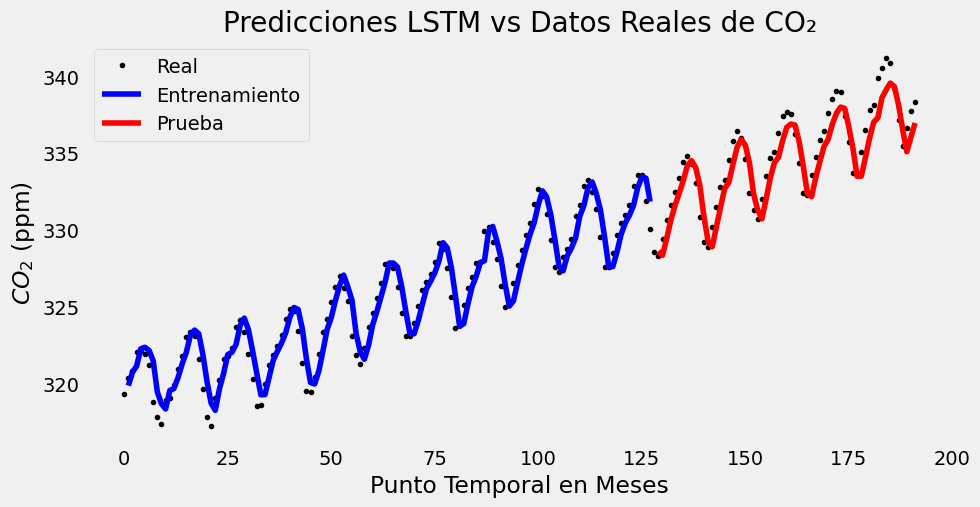

In [42]:
# Hacer predicciones
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)

# Desnormalizar (invertir la transformación)
trainPredict = scaler.inverse_transform(trainPredict)
trainYTrue = scaler.inverse_transform(trainY.reshape(-1, 1))
testPredict = scaler.inverse_transform(testPredict)
testYTrue = scaler.inverse_transform(testY.reshape(-1, 1))

# Calcular RMSE (Error Cuadrático Medio Raíz)
trainScore = math.sqrt(mean_squared_error(trainYTrue, trainPredict))
print('Puntaje Entrenamiento: %.2f RMSE (ppm)' % trainScore)
testScore = math.sqrt(mean_squared_error(testYTrue, testPredict))
print('Puntaje Prueba: %.2f RMSE (ppm)' % testScore)

# Visualizar resultados
plt.figure(figsize=[10, 5])
plt.xlabel('Punto Temporal en Meses')
plt.ylabel('$CO_2$ (ppm)')
plt.grid()
plt.plot(range(len(data)), data, 'k.')
plt.plot(range(look_back, len(trainPredict) + look_back), trainPredict, 'b')
plt.plot(range(len(trainPredict) + 2 * look_back,
               len(trainPredict) + len(testPredict) + 2 * look_back), testPredict, 'r')
plt.legend(['Real', 'Entrenamiento', 'Prueba'])
plt.title('Predicciones LSTM vs Datos Reales de CO₂')
plt.show()

The RMSE indicates the average error in the same units as the data (ppm). An RMSE of 2 ppm means that, on average, the model is off by ±2 parts per million. The lower the RMSE, the better the model.

# Improving Results
### What is required?
Experiment with three improvement strategies and document the results:
### Strategy A: Increase the number of epochs

In [43]:
# Estrategia A: Más épocas
model_A = Sequential()
model_A.add(LSTM(4, input_shape=(1, look_back)))
model_A.add(Dense(1))
model_A.compile(loss='mean_squared_error', optimizer='adam')
model_A.fit(trainX, trainY, epochs=100, batch_size=1, verbose=0)

trainPredict_A = scaler.inverse_transform(model_A.predict(trainX))
testPredict_A = scaler.inverse_transform(model_A.predict(testX))
print('RMSE Entrenamiento (100 épocas):', math.sqrt(mean_squared_error(trainYTrue, trainPredict_A)))
print('RMSE Prueba (100 épocas):', math.sqrt(mean_squared_error(testYTrue, testPredict_A)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/4 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
RMSE Entrenamiento (100 épocas): 1.1222296087936776
RMSE Prueba (100 épocas): 1.6159281226782192


With more epochs, the model has more opportunities to minimize error. However, if it goes too far, it may overfit (memorize the training data without generalizing).

### Strategy B: Increase the lookback

In [44]:
# Estrategia B: Mayor look_back (usar más historia)
look_back_B = 12  # Usar 12 meses anteriores (un año completo)

trainX_B, trainY_B = split_X_y(norm_train, look_back_B)
testX_B, testY_B = split_X_y(norm_test, look_back_B)

trainX_B = np.reshape(trainX_B, (trainX_B.shape[0], 1, trainX_B.shape[1]))
testX_B = np.reshape(testX_B, (testX_B.shape[0], 1, testX_B.shape[1]))

model_B = Sequential()
model_B.add(LSTM(4, input_shape=(1, look_back_B)))
model_B.add(Dense(1))
model_B.compile(loss='mean_squared_error', optimizer='adam')
model_B.fit(trainX_B, trainY_B, epochs=100, batch_size=1, verbose=0)

trainPredict_B = scaler.inverse_transform(model_B.predict(trainX_B))
testPredict_B = scaler.inverse_transform(model_B.predict(testX_B))
print('RMSE Entrenamiento (look_back=12):', math.sqrt(mean_squared_error(
    trainYTrue[look_back_B-1:], trainPredict_B)))
print('RMSE Prueba (look_back=12):', math.sqrt(mean_squared_error(
    testYTrue[look_back_B-1:], testPredict_B)))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
RMSE Entrenamiento (look_back=12): 0.6162481039842141
RMSE Prueba (look_back=12): 1.467760848691232


With look_back=12, the model can view a full year of historical data before making a prediction. This is particularly useful because CO₂ data exhibits annual cycles. With more context, the LSTM can better capture this periodicity.

### Strategy C: Modify the Architecture

In [45]:
# Estrategia C: Arquitectura más profunda con Dropout para evitar sobreajuste
from keras.layers import Dropout

look_back_C = 6

trainX_C, trainY_C = split_X_y(norm_train, look_back_C)
testX_C, testY_C = split_X_y(norm_test, look_back_C)

trainX_C = np.reshape(trainX_C, (trainX_C.shape[0], 1, trainX_C.shape[1]))
testX_C = np.reshape(testX_C, (testX_C.shape[0], 1, testX_C.shape[1]))

model_C = Sequential()
# Primera capa LSTM con return_sequences=True para apilar otra capa LSTM
model_C.add(LSTM(16, return_sequences=True, input_shape=(1, look_back_C)))
model_C.add(Dropout(0.2))  # Apaga aleatoriamente el 20% de neuronas → regularización
model_C.add(LSTM(8))       # Segunda capa LSTM
model_C.add(Dense(1))

model_C.compile(loss='mean_squared_error', optimizer='adam')
model_C.fit(trainX_C, trainY_C, epochs=100, batch_size=1, verbose=0)

trainPredict_C = scaler.inverse_transform(model_C.predict(trainX_C))
testPredict_C = scaler.inverse_transform(model_C.predict(testX_C))
print('RMSE Entrenamiento (arquitectura profunda):', math.sqrt(mean_squared_error(
    trainYTrue[look_back_C-1:], trainPredict_C)))
print('RMSE Prueba (arquitectura profunda):', math.sqrt(mean_squared_error(
    testYTrue[look_back_C-1:], testPredict_C)))

model_C.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
RMSE Entrenamiento (arquitectura profunda): 0.7112551388278349
RMSE Prueba (arquitectura profunda): 2.8893213580097097


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 1, 16)          │         1,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1, 16)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_6 (LSTM)                   │ (None, 8)              │           800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,845 (26.74 KB)

 Trainable params: 2,281 (8.91 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,564 (17.83 KB)

| Component                    | Description                                                                                               |
|:------------------------------|:----------------------------------------------------------------------------------------------------------|
| LSTM(16, return_sequences=True) | First LSTM layer with 16 neurons. Returns the entire sequence to feed the next LSTM layer.      |
| Dropout(0.2)                | Regularization: Randomly turns off 20% of neurons during training to prevent overfitting. |
| LSTM(8)                     | Second LSTM layer with 8 neurons. Returns only the last state.                                        |
| Dense(1)                    | Output layer: Produces a numerical prediction.                                                        |

### Final Comparison of Results

In [46]:
# Tabla comparativa de RMSE
print("=" * 50)
print("COMPARACIÓN DE MODELOS — Serie CO₂ Mauna Loa")
print("=" * 50)
print(f"{'Modelo':<35} {'RMSE Train':>12} {'RMSE Test':>12}")
print("-" * 50)
print(f"{'Base (LSTM 4 units, 20 épocas)':<35} {trainScore:>12.4f} {testScore:>12.4f}")
print("(Ejecuta los modelos A, B, C y completa aquí)")
print("=" * 50)

COMPARACIÓN DE MODELOS — Serie CO₂ Mauna Loa
Modelo                                RMSE Train    RMSE Test
--------------------------------------------------
Base (LSTM 4 units, 20 épocas)            1.1208       1.2946
(Ejecuta los modelos A, B, C y completa aquí)


# Conclusions

Recurrent neural networks proved to be highly effective for modeling sequential and temporal data because they can learn dependencies between observations over time. Throughout the experiments, the SimpleRNN model successfully captured short-term patterns in the PM2.5 series; however, its memory limitations reduced forecasting accuracy when compared with more advanced LSTM architectures. The LSTM networks achieved better predictive performance because their gating mechanisms allowed them to preserve long-term temporal information and mitigate the vanishing-gradient problem commonly encountered in traditional recurrent networks.

The results also demonstrated that hyperparameter tuning played a critical role in forecasting performance. Increasing the number of epochs, recurrent units, and look_back windows substantially improved prediction accuracy by enabling the networks to learn more complex temporal structures. Nevertheless, increasing model complexity also raised computational cost and the risk of overfitting, highlighting the importance of balancing predictive performance and generalization capacity.

Additionally, data normalization using MinMaxScaler significantly improved training stability and allowed the neural networks to converge more efficiently during optimization. Residual analysis further confirmed that the optimized LSTM architectures generalized appropriately and successfully captured most of the temporal structure present in the datasets. Overall, the experiments demonstrated that advanced LSTM architectures are particularly suitable for time-series forecasting problems involving seasonality, long-term trends, and nonlinear temporal dependencies.

# GitHub link

The repository containing the complete implementation of the forecasting models, datasets, preprocessing procedures, and experimental notebooks developed for this activity is available at the following link: https://github.com/Nelmoro/Recurrent-Neural-Networks-and-LSTMs-for-Time-Series-Forecasting. The repository includes all Python code used for data preparation, RNN and LSTM model construction, hyperparameter tuning, evaluation metrics, and graphical visualizations presented throughout this report.

# References
Chollet, F. (2021). Deep Learning with Python (2nd ed.). Manning Publications.

Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.

Brownlee, J. (2018). Deep Learning for Time Series Forecasting. Machine Learning Mastery.

TensorFlow. (2026). Keras Documentation. https://keras.io/

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., ... & Duchesnay, E. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825–2830.

Hochreiter, S., & Schmidhuber, J. (1997). Long Short-Term Memory. Neural Computation, 9(8), 1735–1780.